# Fast and Robust Active Cooling / Vacuum Reset

This notebook reproduces the main saved results of the comparative cooling study.


## Environment Setup


In [1]:
from pathlib import Path
import csv
import json
import matplotlib.pyplot as plt


def locate_study_dir() -> Path:
    study_name = 'fast_robust_storage_vacuum_reset_comparison'
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        direct = base / study_name
        nested = base / 'studies' / study_name
        for candidate in (direct, nested, base):
            if (candidate / 'data' / 'study_results.json').exists() and (candidate / 'figures').exists():
                return candidate
    raise FileNotFoundError('Could not locate the study directory containing data/study_results.json')


STUDY_DIR = locate_study_dir()
DATA_DIR = STUDY_DIR / 'data'
FIG_DIR = STUDY_DIR / 'figures'
ART_DIR = STUDY_DIR / 'artifacts'
study_results = json.loads((DATA_DIR / 'study_results.json').read_text(encoding='utf-8'))
print('Study dir:', STUDY_DIR)


Study dir: C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\fast_robust_storage_vacuum_reset_comparison


## User-Tunable Parameters


In [2]:
storage_threshold = 0.01
transmon_threshold = 1e-3
coherent_alpha = 1.0
thermal_nbar = 0.5
t1_scale = 1.0
t2_scale = 1.0
readout_kappa_scale = 1.0
print({'storage_threshold': storage_threshold, 'transmon_threshold': transmon_threshold, 'coherent_alpha': coherent_alpha, 'thermal_nbar': thermal_nbar, 't1_scale': t1_scale, 't2_scale': t2_scale, 'readout_kappa_scale': readout_kappa_scale})


{'storage_threshold': 0.01, 'transmon_threshold': 0.001, 'coherent_alpha': 1.0, 'thermal_nbar': 0.5, 't1_scale': 1.0, 't2_scale': 1.0, 'readout_kappa_scale': 1.0}


## Derived Objects


In [3]:
with (DATA_DIR / 'scheme_summary.csv').open() as handle:
    scheme_summary = list(csv.DictReader(handle))
with (DATA_DIR / 'initial_state_summary.csv').open() as handle:
    initial_state_summary = list(csv.DictReader(handle))
for row in scheme_summary:
    print(row['scheme_label'], row['robustness_score'], row['baseline_storage_n_final'])


Pulsed ladder 0.9693224226943806 0.004062644721050515
Continuous bright-state 0.9652133728529398 0.0017007724070596203
Continuous Raman-like 0.9815932310473439 0.00031336098993885094
Effective benchmark 0.9994369119827202 0.0008378245990915134


## Step-by-step Reproduction


In [4]:
# --- Load saved results (default) ---
print(study_results['headline_answers'])

# --- Re-run with current parameters ---
# import sys
# sys.path.insert(0, str(STUDY_DIR / 'scripts'))
# from run_study import main
# main()


{'best_overall_scheme': 'Continuous Raman-like', 'fastest_scheme': 'Pulsed ladder', 'most_robust_scheme': 'Continuous Raman-like', 'recommended_first_experiment': 'Pulsed ladder with shorter ringdown than the conservative 4/κ choice.', 'best_long_term_direction': 'Detuned Raman-like readout-assisted cooling with a stronger readout bath.'}


## Validation


In [5]:
with (DATA_DIR / 'convergence_summary.csv').open() as handle:
    convergence = list(csv.DictReader(handle))
convergence[:3]


[{'scheme_key': 'pulsed_ladder',
  'scheme_label': 'Pulsed `g-f` ladder',
  'time_to_threshold_ns': '',
  'e_fold_time_ns': '11.000000000000002',
  'estimated_decay_rate_hz': '430419789.84112954',
  'final_storage_n': '0.004061637265763228',
  'final_readout_n': '0.01752940830239024',
  'final_transmon_excited': '0.008991089351311099',
  'final_ground_vacuum': '0.9694178650805354',
  'steady_storage_n': '0.004062644721050515',
  'steady_transmon_excited': '0.009019988588555735',
  'steady_ground_vacuum': '0.9639676866307507',
  'max_e_population': '0.004592245815601059',
  'max_f_population': '0.9943587934778528',
  'max_hplus_population': '0.0',
  'times_ns': '[0.0, 0.5, 1.0, 1.5000000000000002, 2.0, 2.5, 3.0000000000000004, 3.5000000000000004, 4.0, 4.500000000000001, 5.0, 5.500000000000001, 6.000000000000001, 6.5, 7.000000000000001, 7.500000000000001, 8.0, 8.5, 9.000000000000002, 9.5, 10.0, 10.500000000000002, 11.000000000000002, 11.5, 12.000000000000002, 12.500000000000002, 13.0, 13

## Key Figures


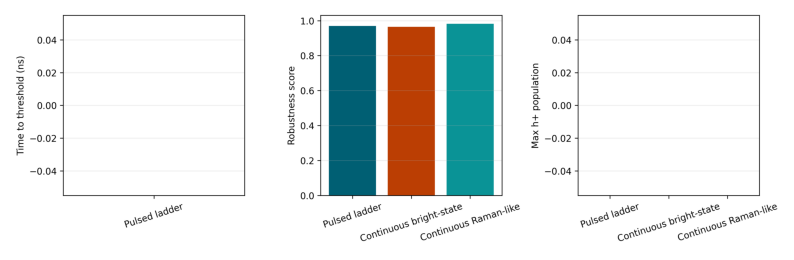

In [6]:
fig = plt.imread(FIG_DIR / 'scheme_comparison_summary.png')
plt.figure(figsize=(10, 3.5))
plt.imshow(fig)
plt.axis('off')
plt.show()


## Summary

The saved data show that the continuous Raman-like protocol is the best overall physical scheme, the pulsed ladder is the fastest practical path and the best first experiment, and a stronger readout bath improves the Raman-like architecture further.
